# EURUSD H4 Group 1 Momentum Walk-Forward Strategy

This notebook investigates the stability of **Feature Group 1: Pure Short-Term Momentum** using EURUSD H4 data, yearly walk-forward retraining, and `vectorbt` portfolio analytics.

Group 1 features:
- Lagged returns: `ret_1`, `ret_2`, `ret_3`, `ret_5`, `ret_10`
- EWMA returns: spans 5, 10, 20
- Rolling linear momentum slopes over 10 and 20 bars

The notebook uses the `adonys` conda environment and evaluates shallow tree regressors only.

## 1. Imports and Configuration

In [1]:
from __future__ import annotations

import warnings
from dataclasses import dataclass
from pathlib import Path
from datetime import datetime, timedelta, timezone
from typing import Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import vectorbt as vbt

from scipy.stats import pearsonr, spearmanr
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

try:
    import MetaTrader5 as mt5
except ImportError:
    mt5 = None

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")

RANDOM_STATE = 42
SYMBOL = "EURUSD"
TIMEFRAME = "H4"
HORIZONS = [1, 3, 6]
MAX_TREE_DEPTH = 3

# Portfolio assumptions. Treat these as sensitivity parameters, not facts.
INIT_CASH = 100_000
FEE_RATE = 0.00002       # 0.2 bps per order placeholder.
SLIPPAGE = 0.00001       # 0.1 bps placeholder.
ANNUAL_VOL_TARGET = 0.10
MAX_GROSS_EXPOSURE = 1.0
ENTRY_THRESHOLD = 0.0
BARS_PER_YEAR = 252 * 6  # Approximate EURUSD H4 weekday bars.

## 2. Data Loading

The notebook defaults to the local EURUSD H4 CSV already in this project. Set `REFRESH_FROM_MT5 = True` to pull a fresh 7-year sample from MetaTrader 5.

In [2]:
def find_project_root(start: Optional[Path] = None) -> Path:
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "README.md").exists() and (candidate / "metalib").exists():
            return candidate
    return start


PROJECT_ROOT = find_project_root()
LOCAL_H4_CSV = PROJECT_ROOT / "metalib" / "data" / "eurusd" / "eurusd_h4_latest.csv"
REFRESH_FROM_MT5 = False
SAVE_MT5_REFRESH = True
YEARS_BACK = 7

print(f"Project root: {PROJECT_ROOT}")
print(f"Local H4 CSV: {LOCAL_H4_CSV}")

Project root: C:\Users\Hermes\PycharmProjects\metalib
Local H4 CSV: C:\Users\Hermes\PycharmProjects\metalib\metalib\data\eurusd\eurusd_h4_latest.csv


In [3]:
def normalize_ohlc_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out = out.rename(columns={c: c.lower() for c in out.columns})
    out = out.rename(columns={
        "open": "Open",
        "high": "High",
        "low": "Low",
        "close": "Close",
        "tick_volume": "TickVolume",
        "volume": "Volume",
    })
    missing = [c for c in ["Open", "High", "Low", "Close"] if c not in out.columns]
    if missing:
        raise ValueError(f"Missing OHLC columns: {missing}")
    return out


def load_local_h4_csv(path: Path = LOCAL_H4_CSV) -> pd.DataFrame:
    df = pd.read_csv(path)
    time_col = "time" if "time" in df.columns else df.columns[0]
    df[time_col] = pd.to_datetime(df[time_col], utc=True)
    df = df.set_index(time_col).sort_index()
    df = normalize_ohlc_columns(df)
    df = df[~df.index.duplicated(keep="last")]
    return df.dropna(subset=["Open", "High", "Low", "Close"])


def mt5_timeframe(name: str):
    mapping = {"H1": mt5.TIMEFRAME_H1, "H4": mt5.TIMEFRAME_H4, "D1": mt5.TIMEFRAME_D1}
    return mapping[name.upper()]


def download_mt5_ohlc(symbol: str = SYMBOL, timeframe: str = TIMEFRAME, years_back: int = YEARS_BACK) -> pd.DataFrame:
    if mt5 is None:
        raise ImportError("MetaTrader5 is not installed in this kernel.")
    if not mt5.initialize():
        code, message = mt5.last_error()
        raise RuntimeError(f"MT5 initialization failed: {code} - {message}")
    try:
        info = mt5.symbol_info(symbol)
        if info is None:
            similar = [s.name for s in mt5.symbols_get("*EUR*USD*") or []][:20]
            raise ValueError(f"Symbol {symbol!r} not found. Similar symbols: {similar}")
        if not info.visible and not mt5.symbol_select(symbol, True):
            raise RuntimeError(f"Could not select {symbol!r} in MT5 Market Watch.")

        end_utc = datetime.now(timezone.utc)
        start_utc = end_utc - timedelta(days=int(365.25 * years_back))
        rates = mt5.copy_rates_range(symbol, mt5_timeframe(timeframe), start_utc, end_utc)
        if rates is None or len(rates) == 0:
            code, message = mt5.last_error()
            raise RuntimeError(f"No MT5 rates returned: {code} - {message}")
        df = pd.DataFrame(rates)
        df["time"] = pd.to_datetime(df["time"], unit="s", utc=True)
        df = df.set_index("time").sort_index()
        return normalize_ohlc_columns(df).dropna(subset=["Open", "High", "Low", "Close"])
    finally:
        mt5.shutdown()


if REFRESH_FROM_MT5:
    raw = download_mt5_ohlc()
    if SAVE_MT5_REFRESH:
        LOCAL_H4_CSV.parent.mkdir(parents=True, exist_ok=True)
        raw.reset_index().to_csv(LOCAL_H4_CSV, index=False)
else:
    raw = load_local_h4_csv()

print(raw.shape)
display(raw.head())
display(raw.tail())

(10000, 7)


,Open,High,Low,Close,TickVolume,spread,real_volume
time,,,,,,,
2019-11-26 12:00:00+00:00,1.10141,1.10248,1.10135,1.10172,5229,1,0
2019-11-26 16:00:00+00:00,1.10172,1.10219,1.10072,1.10199,7797,1,0
2019-11-26 20:00:00+00:00,1.10199,1.10255,1.10173,1.10194,3458,1,0
2019-11-27 00:00:00+00:00,1.10194,1.10246,1.10151,1.10161,2389,1,0
2019-11-27 04:00:00+00:00,1.10161,1.10179,1.10081,1.10094,1804,1,0


,Open,High,Low,Close,TickVolume,spread,real_volume
time,,,,,,,
2026-05-01 04:00:00+00:00,1.17270,1.17358,1.17245,1.17262,4027,11,0
2026-05-01 08:00:00+00:00,1.17262,1.17474,1.17182,1.17429,8292,11,0
2026-05-01 12:00:00+00:00,1.17429,1.17683,1.17301,1.17570,8037,11,0
2026-05-01 16:00:00+00:00,1.17569,1.17846,1.17370,1.17375,11894,11,0
2026-05-01 20:00:00+00:00,1.17375,1.17398,1.17140,1.17140,5301,11,0


## 3. Group 1 Features and Targets

In [4]:
def rolling_slope(values: pd.Series, window: int) -> pd.Series:
    x = np.arange(window, dtype=float)
    x = x - x.mean()
    denom = np.sum(x ** 2)

    def _slope(y: np.ndarray) -> float:
        if np.any(~np.isfinite(y)):
            return np.nan
        return float(np.dot(x, y - y.mean()) / denom)

    return values.rolling(window).apply(_slope, raw=True)


def make_group1_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    close = out["Close"]
    ret = close.pct_change()
    log_close = np.log(close)

    out["ret_1"] = ret
    for lag in [2, 3, 5, 10]:
        out[f"ret_{lag}"] = close.pct_change(lag)
    for span in [5, 10, 20]:
        out[f"ewma_ret_{span}"] = ret.ewm(span=span, adjust=False, min_periods=span).mean()
    out["momentum_slope_10"] = rolling_slope(log_close, 10)
    out["momentum_slope_20"] = rolling_slope(log_close, 20)
    out["vol_20"] = ret.rolling(20).std()
    return out


def add_targets(df: pd.DataFrame, horizons: Iterable[int] = HORIZONS, vol_window: int = 20) -> pd.DataFrame:
    out = df.copy()
    close = out["Close"]
    ret = close.pct_change()
    past_bar_vol = ret.rolling(vol_window).std()
    for h in horizons:
        future_return = close.shift(-h) / close - 1.0
        pred_vol = past_bar_vol * np.sqrt(h)
        out[f"future_return_{h}"] = future_return
        out[f"pred_vol_{h}"] = pred_vol
        out[f"target_{h}"] = future_return / pred_vol.replace(0, np.nan)
    return out


GROUP1_FEATURES = [
    "ret_1", "ret_2", "ret_3", "ret_5", "ret_10",
    "ewma_ret_5", "ewma_ret_10", "ewma_ret_20",
    "momentum_slope_10", "momentum_slope_20",
]

features = make_group1_features(raw)
data = add_targets(features)
display(data[GROUP1_FEATURES + ["vol_20"]].tail())
display(data[[f"target_{h}" for h in HORIZONS]].describe().T)

,ret_1,ret_2,ret_3,ret_5,ret_10,ewma_ret_5,ewma_ret_10,ewma_ret_20,momentum_slope_10,momentum_slope_20,vol_20
time,,,,,,,,,,,
2026-05-01 04:00:00+00:00,-0.000077,-0.000281,0.000111,0.004050,0.002385,0.000345,0.000323,0.000177,0.000625,0.000008,0.001044
2026-05-01 08:00:00+00:00,0.001424,0.001347,0.001142,0.004345,0.005041,0.000705,0.000523,0.000296,0.000758,0.000079,0.001089
2026-05-01 12:00:00+00:00,0.001201,0.002627,0.002550,0.002738,0.006998,0.000870,0.000647,0.000382,0.000846,0.000156,0.001104
2026-05-01 16:00:00+00:00,-0.001659,-0.000460,0.000964,0.000682,0.005035,0.000027,0.000227,0.000188,0.000779,0.000190,0.001157
2026-05-01 20:00:00+00:00,-0.002002,-0.003657,-0.002461,-0.001117,0.004674,-0.000649,-0.000178,-0.000021,0.000431,0.000183,0.001247


,count,mean,std,min,25%,50%,75%,max
target_1,9979.0,0.005570,1.128853,-9.758994,-0.532009,0.006986,0.544645,7.189658
target_3,9977.0,0.010459,1.139273,-6.363690,-0.602736,0.002582,0.598947,8.377662
target_6,9974.0,0.012892,1.114515,-6.808613,-0.648008,-0.016319,0.649563,7.454879


## 4. Yearly Walk-Forward Training

Each test fold is one calendar year. The model trains on all prior data, with a purge gap equal to the forecast horizon.

In [5]:
@dataclass
class YearFold:
    test_year: int
    train_start: pd.Timestamp
    train_end: pd.Timestamp
    test_start: pd.Timestamp
    test_end: pd.Timestamp
    n_train: int
    n_test: int


def make_model_registry() -> Dict[str, object]:
    return {
        "DecisionTree": DecisionTreeRegressor(max_depth=MAX_TREE_DEPTH, min_samples_leaf=50, random_state=RANDOM_STATE),
        "RandomForest": RandomForestRegressor(n_estimators=100, max_depth=MAX_TREE_DEPTH, min_samples_leaf=50, random_state=RANDOM_STATE, n_jobs=-1),
        "XGBoost": XGBRegressor(n_estimators=100, max_depth=MAX_TREE_DEPTH, learning_rate=0.1, subsample=0.8, colsample_bytree=0.8, objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1),
    }


def yearly_splits(frame: pd.DataFrame, min_train_years: int = 3, purge: int = 6):
    years = sorted(frame.index.year.unique())
    for test_year in years[min_train_years:]:
        test_idx = np.flatnonzero(frame.index.year == test_year)
        train_idx = np.flatnonzero(frame.index.year < test_year)
        train_idx = train_idx[train_idx < max(0, test_idx[0] - purge)]
        if len(train_idx) >= 500 and len(test_idx) > 0:
            yield test_year, train_idx, test_idx


def safe_corr(y_true: np.ndarray, y_pred: np.ndarray, method: str) -> float:
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    if mask.sum() < 10 or np.nanstd(y_true[mask]) == 0 or np.nanstd(y_pred[mask]) == 0:
        return np.nan
    return float(pearsonr(y_true[mask], y_pred[mask])[0]) if method == "pearson" else float(spearmanr(y_true[mask], y_pred[mask]).correlation)


def prediction_metrics(frame: pd.DataFrame, horizon: int) -> Dict[str, float]:
    y = frame[f"target_{horizon}"].to_numpy()
    p = frame["prediction"].to_numpy()
    nonzero = (y != 0) & (p != 0) & np.isfinite(y) & np.isfinite(p)
    return {
        "rmse": float(np.sqrt(mean_squared_error(y, p))),
        "mae": float(mean_absolute_error(y, p)),
        "directional_accuracy": float((np.sign(y[nonzero]) == np.sign(p[nonzero])).mean()) if nonzero.sum() else np.nan,
        "pearson_ic": safe_corr(y, p, "pearson"),
        "spearman_ic": safe_corr(y, p, "spearman"),
    }


def run_walk_forward(horizon: int, model_name: str, model) -> Tuple[pd.DataFrame, List[YearFold], Dict[str, float]]:
    target_col = f"target_{horizon}"
    cols = GROUP1_FEATURES + [target_col, f"future_return_{horizon}", f"pred_vol_{horizon}", "Close"]
    frame = data[cols].replace([np.inf, -np.inf], np.nan).dropna().copy()
    X, y = frame[GROUP1_FEATURES], frame[target_col]
    pred = pd.Series(index=frame.index, dtype=float, name="prediction")
    folds: List[YearFold] = []

    for test_year, train_idx, test_idx in yearly_splits(frame, min_train_years=3, purge=horizon):
        fitted = clone(model)
        fitted.fit(X.iloc[train_idx], y.iloc[train_idx])
        pred.iloc[test_idx] = fitted.predict(X.iloc[test_idx])
        folds.append(YearFold(test_year, frame.index[train_idx[0]], frame.index[train_idx[-1]], frame.index[test_idx[0]], frame.index[test_idx[-1]], len(train_idx), len(test_idx)))

    oos = frame.assign(prediction=pred).dropna(subset=["prediction"])
    metrics = prediction_metrics(oos, horizon)
    metrics.update({"horizon": horizon, "model": model_name, "n_oos": len(oos), "folds": len(folds)})
    return oos, folds, metrics

In [6]:
models = make_model_registry()
wf_predictions: Dict[Tuple[int, str], pd.DataFrame] = {}
wf_folds: Dict[Tuple[int, str], List[YearFold]] = {}
metric_rows = []

for horizon in HORIZONS:
    for model_name, model in models.items():
        oos, folds, metrics = run_walk_forward(horizon, model_name, model)
        wf_predictions[(horizon, model_name)] = oos
        wf_folds[(horizon, model_name)] = folds
        metric_rows.append(metrics)
        print(f"Done h={horizon} {model_name}: {len(oos):,} OOS bars, {len(folds)} yearly folds")

wf_metrics = pd.DataFrame(metric_rows).sort_values(["spearman_ic", "directional_accuracy"], ascending=False)
display(wf_metrics)

Done h=1 DecisionTree: 6,732 OOS bars, 5 yearly folds
Done h=1 RandomForest: 6,732 OOS bars, 5 yearly folds
Done h=1 XGBoost: 6,732 OOS bars, 5 yearly folds
Done h=3 DecisionTree: 6,730 OOS bars, 5 yearly folds
Done h=3 RandomForest: 6,730 OOS bars, 5 yearly folds
Done h=3 XGBoost: 6,730 OOS bars, 5 yearly folds
Done h=6 DecisionTree: 6,727 OOS bars, 5 yearly folds
Done h=6 RandomForest: 6,727 OOS bars, 5 yearly folds
Done h=6 XGBoost: 6,727 OOS bars, 5 yearly folds


,rmse,mae,directional_accuracy,pearson_ic,spearman_ic,horizon,model,n_oos,folds
3,1.157800,0.831466,0.502752,0.006796,0.005148,3,DecisionTree,6730,5
1,1.139334,0.778047,0.513578,-0.007550,0.003911,1,RandomForest,6732,5
5,1.164732,0.840833,0.501711,0.006590,0.003147,3,XGBoost,6730,5
2,1.150038,0.789475,0.511191,-0.005410,0.000284,1,XGBoost,6732,5
4,1.153275,0.828233,0.502306,0.000224,-0.001631,3,RandomForest,6730,5
0,1.143779,0.782026,0.503283,-0.006411,-0.002346,1,DecisionTree,6732,5
8,1.146320,0.857489,0.497769,-0.007459,-0.002977,6,XGBoost,6727,5
7,1.131392,0.844732,0.490181,-0.011956,-0.015545,6,RandomForest,6727,5
6,1.139144,0.850908,0.497322,-0.020570,-0.016933,6,DecisionTree,6727,5


## 5. Convert Predictions to Positions

The signal is long for positive predictions and short for negative predictions. Exposure is scaled by ex-ante volatility and clipped. Orders are shifted by one bar to avoid same-close execution bias.

In [7]:
def target_percent_from_predictions(oos: pd.DataFrame, horizon: int) -> pd.Series:
    pred = oos["prediction"].astype(float)
    pred_vol = oos[f"pred_vol_{horizon}"].astype(float).replace(0, np.nan)
    direction = pd.Series(0.0, index=oos.index)
    direction[pred > ENTRY_THRESHOLD] = 1.0
    direction[pred < -ENTRY_THRESHOLD] = -1.0

    horizon_annualizer = np.sqrt(BARS_PER_YEAR / horizon)
    gross = ANNUAL_VOL_TARGET / (pred_vol * horizon_annualizer)
    gross = gross.replace([np.inf, -np.inf], np.nan).clip(0.0, MAX_GROSS_EXPOSURE).fillna(0.0)
    return (direction * gross).clip(-MAX_GROSS_EXPOSURE, MAX_GROSS_EXPOSURE).shift(1).fillna(0.0).rename("target_percent")


def make_portfolio(close: pd.Series, target_percent: pd.Series) -> vbt.Portfolio:
    close = close.reindex(target_percent.index).astype(float)
    return vbt.Portfolio.from_orders(
        close=close,
        size=target_percent,
        size_type="targetpercent",
        direction="both",
        fees=FEE_RATE,
        slippage=SLIPPAGE,
        init_cash=INIT_CASH,
        freq="4h",
    )


def annualized_sharpe(returns: pd.Series) -> float:
    r = returns.replace([np.inf, -np.inf], np.nan).dropna()
    return np.nan if r.empty or r.std(ddof=0) == 0 else float(np.sqrt(BARS_PER_YEAR) * r.mean() / r.std(ddof=0))


def max_drawdown(returns: pd.Series) -> float:
    equity = (1.0 + returns.fillna(0.0)).cumprod()
    return float((equity / equity.cummax() - 1.0).min())


def summarize_returns(returns: pd.Series, target: pd.Series) -> Dict[str, float]:
    r = returns.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    turnover = target.diff().abs().fillna(target.abs())
    return {
        "total_return": float((1.0 + r).prod() - 1.0),
        "ann_return": float((1.0 + r).prod() ** (BARS_PER_YEAR / max(len(r), 1)) - 1.0),
        "ann_vol": float(r.std(ddof=0) * np.sqrt(BARS_PER_YEAR)),
        "sharpe": annualized_sharpe(r),
        "max_drawdown": max_drawdown(r),
        "avg_abs_exposure": float(target.abs().mean()),
        "avg_turnover_per_bar": float(turnover.mean()),
    }


def yearly_table(returns: pd.Series, target: pd.Series) -> pd.DataFrame:
    rows = []
    for year, r in returns.groupby(returns.index.year):
        t = target.reindex(r.index).fillna(0.0)
        rows.append({
            "year": int(year),
            "bars": len(r),
            "return": float((1.0 + r.fillna(0.0)).prod() - 1.0),
            "sharpe": annualized_sharpe(r),
            "max_drawdown": max_drawdown(r),
            "avg_abs_exposure": float(t.abs().mean()),
            "long_frac": float((t > 0).mean()),
            "short_frac": float((t < 0).mean()),
            "flat_frac": float((t == 0).mean()),
        })
    return pd.DataFrame(rows)

## 6. vectorbt Portfolio Evaluation

In [8]:
portfolios = {}
portfolio_returns = {}
target_positions = {}
portfolio_rows = []
yearly_tables = {}

for (horizon, model_name), oos in wf_predictions.items():
    target = target_percent_from_predictions(oos, horizon)
    pf = make_portfolio(oos["Close"], target)
    returns = pf.returns().rename("strategy_return")

    portfolios[(horizon, model_name)] = pf
    portfolio_returns[(horizon, model_name)] = returns
    target_positions[(horizon, model_name)] = target
    yearly_tables[(horizon, model_name)] = yearly_table(returns, target)

    summary = summarize_returns(returns, target)
    summary.update({"horizon": horizon, "model": model_name})
    portfolio_rows.append(summary)

portfolio_summary = pd.DataFrame(portfolio_rows).sort_values(["sharpe", "total_return"], ascending=False)
display(portfolio_summary)

,total_return,ann_return,ann_vol,sharpe,max_drawdown,avg_abs_exposure,avg_turnover_per_bar,horizon,model
4,0.039140,0.008663,0.076072,0.151423,-0.105841,0.967897,0.478078,3,RandomForest
1,0.018199,0.004059,0.076073,0.091285,-0.127718,0.967907,0.665974,1,RandomForest
5,-0.031071,-0.007066,0.076070,-0.055186,-0.247081,0.967897,0.722235,3,XGBoost
3,-0.130604,-0.030954,0.076080,-0.375258,-0.227084,0.967897,0.392017,3,DecisionTree
2,-0.132080,-0.031315,0.076066,-0.380228,-0.253970,0.967907,0.837923,1,XGBoost
7,-0.156396,-0.037505,0.076106,-0.464216,-0.217657,0.967883,0.465269,6,RandomForest
8,-0.175142,-0.042354,0.076110,-0.530542,-0.215387,0.967883,0.715805,6,XGBoost
0,-0.201961,-0.049407,0.076064,-0.628093,-0.257668,0.967907,0.303408,1,DecisionTree
6,-0.211059,-0.051889,0.076081,-0.662291,-0.305500,0.967883,0.360341,6,DecisionTree


## 7. Year-by-Year Stability

In [9]:
best = portfolio_summary.iloc[0]
BEST_HORIZON = int(best["horizon"])
BEST_MODEL = str(best["model"])
BEST_KEY = (BEST_HORIZON, BEST_MODEL)

print(f"Best by strategy Sharpe: horizon={BEST_HORIZON}, model={BEST_MODEL}")
display(best.to_frame("value"))
display(pd.DataFrame([f.__dict__ for f in wf_folds[BEST_KEY]]))
display(yearly_tables[BEST_KEY])

annual = []
for (h, m), table in yearly_tables.items():
    tmp = table.copy()
    tmp["horizon"] = h
    tmp["model"] = m
    annual.append(tmp)
annual = pd.concat(annual, ignore_index=True)

display(annual.pivot_table(index=["horizon", "model"], columns="year", values="return"))
display(annual.pivot_table(index=["horizon", "model"], columns="year", values="sharpe"))

Best by strategy Sharpe: horizon=3, model=RandomForest


,value
total_return,0.03914
ann_return,0.008663
ann_vol,0.076072
sharpe,0.151423
max_drawdown,-0.105841
avg_abs_exposure,0.967897
avg_turnover_per_bar,0.478078
horizon,3
model,RandomForest


,test_year,train_start,train_end,test_start,test_end,n_train,n_test
0,2022,2019-11-29 20:00:00+00:00,2021-12-31 08:00:00+00:00,2022-01-03 00:00:00+00:00,2022-12-30 20:00:00+00:00,3244,1554
1,2023,2019-11-29 20:00:00+00:00,2022-12-30 08:00:00+00:00,2023-01-02 00:00:00+00:00,2023-12-29 20:00:00+00:00,4798,1548
2,2024,2019-11-29 20:00:00+00:00,2023-12-29 08:00:00+00:00,2024-01-02 00:00:00+00:00,2024-12-31 20:00:00+00:00,6346,1560
3,2025,2019-11-29 20:00:00+00:00,2024-12-31 08:00:00+00:00,2025-01-02 00:00:00+00:00,2025-12-31 20:00:00+00:00,7906,1555
4,2026,2019-11-29 20:00:00+00:00,2025-12-31 08:00:00+00:00,2026-01-02 00:00:00+00:00,2026-05-01 08:00:00+00:00,9461,513


,year,bars,return,sharpe,max_drawdown,avg_abs_exposure,long_frac,short_frac,flat_frac
0,2022,1554,0.112029,1.138278,-0.058701,0.907364,0.638996,0.360360,0.000644
1,2023,1548,0.027445,0.390219,-0.084798,0.985728,0.507752,0.492248,0.000000
2,2024,1560,-0.025815,-0.393110,-0.077193,0.994851,0.562821,0.437179,0.000000
3,2025,1555,-0.035224,-0.432570,-0.093176,0.974368,0.501608,0.498392,0.000000
4,2026,513,-0.032320,-1.474322,-0.044924,0.995880,0.536062,0.463938,0.000000


year                      2022      2023      2024      2025      2026
horizon model                                                         
1       DecisionTree -0.035045 -0.121086  0.000536 -0.085402  0.028272
        RandomForest  0.038682  0.021581  0.048921 -0.074524 -0.011516
        XGBoost       0.088407 -0.068490 -0.033187 -0.064214 -0.053802
3       DecisionTree  0.048358 -0.013709 -0.036972 -0.125280 -0.001852
        RandomForest  0.112029  0.027445 -0.025815 -0.035224 -0.032320
        XGBoost       0.058770  0.142879 -0.107757 -0.103886  0.001483
6       DecisionTree  0.063519 -0.117973 -0.080047 -0.093386  0.008393
        RandomForest  0.038581 -0.047793 -0.057501 -0.060821 -0.036310
        XGBoost      -0.025501  0.024039 -0.053198 -0.091930 -0.038603

year                      2022      2023      2024      2025      2026
horizon model                                                         
1       DecisionTree -0.318977 -1.643978  0.038634 -1.132622  1.306544
        RandomForest  0.437142  0.315509  0.803331 -0.977231 -0.496628
        XGBoost       0.917877 -0.886096 -0.516435 -0.832210 -2.496420
3       DecisionTree  0.532390 -0.142244 -0.579489 -1.716993 -0.052803
        RandomForest  1.138278  0.390219 -0.393110 -0.432570 -1.474322
        XGBoost       0.633871  1.780306 -1.815054 -1.400036  0.100082
6       DecisionTree  0.680111 -1.598043 -1.319633 -1.247008  0.417215
        RandomForest  0.436083 -0.599943 -0.927609 -0.784883 -1.669983
        XGBoost      -0.217779  0.346801 -0.853934 -1.226129 -1.780778

## 8. Best Candidate Charts

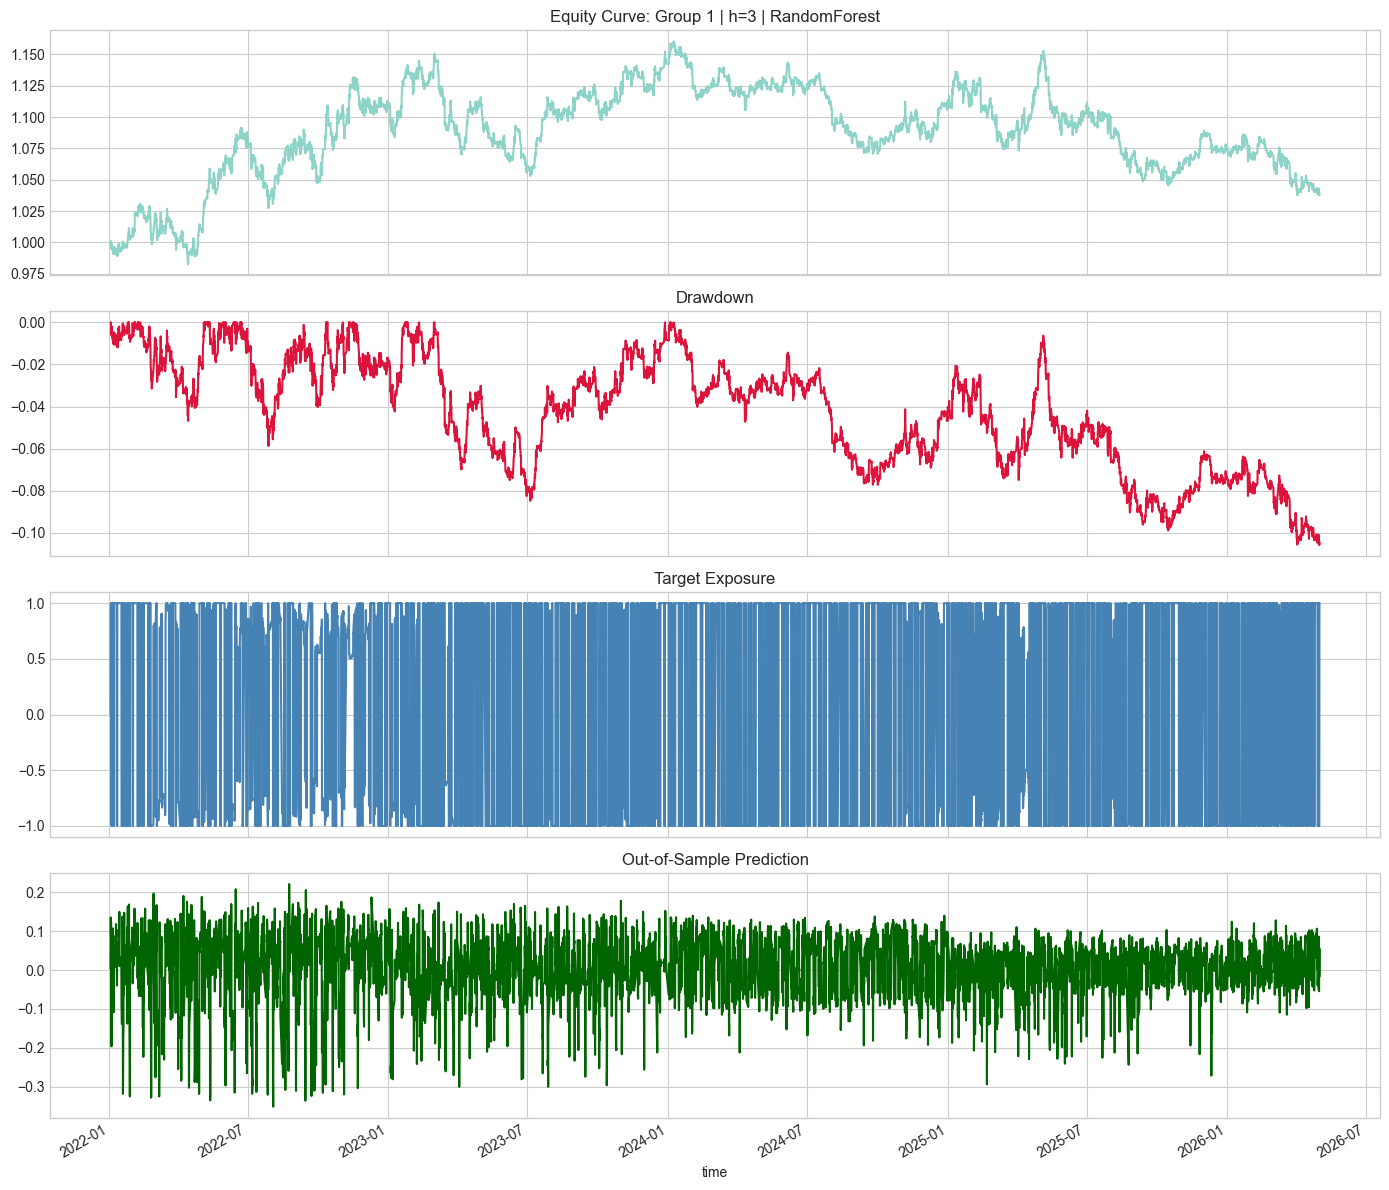

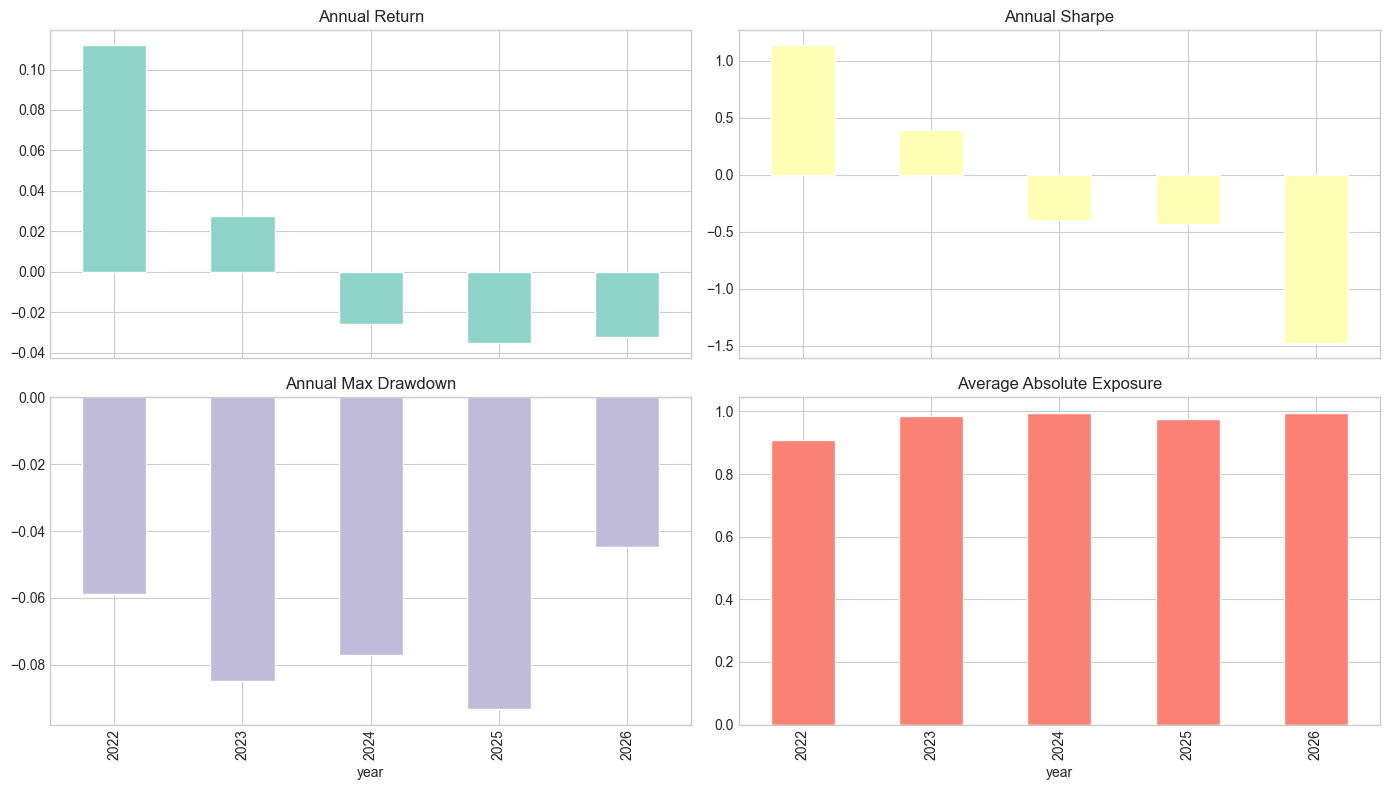

In [13]:
best_returns = portfolio_returns[BEST_KEY]
best_target = target_positions[BEST_KEY]
best_equity = (1.0 + best_returns.fillna(0.0)).cumprod()
best_dd = best_equity / best_equity.cummax() - 1.0

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
best_equity.plot(ax=axes[0], title=f"Equity Curve: Group 1 | h={BEST_HORIZON} | {BEST_MODEL}")
best_dd.plot(ax=axes[1], title="Drawdown", color="crimson")
best_target.plot(ax=axes[2], title="Target Exposure", color="steelblue")
wf_predictions[BEST_KEY]["prediction"].plot(ax=axes[3], title="Out-of-Sample Prediction", color="darkgreen")

plt.tight_layout()
plt.show()

yearly_tables[BEST_KEY].set_index("year")[["return", "sharpe", "max_drawdown", "avg_abs_exposure"]].plot(
    kind="bar", subplots=True, layout=(2, 2), figsize=(14, 8), legend=False,
    title=["Annual Return", "Annual Sharpe", "Annual Max Drawdown", "Average Absolute Exposure"]
)
plt.tight_layout()
plt.show()

## 9. vectorbt Native Statistics

In [11]:
pf = portfolios[BEST_KEY]
display(pf.stats())
display(pf.trades.records_readable.head(20))
print(f"Total trades: {pf.trades.count()}")

Start                         2022-01-03 00:00:00+00:00
End                           2026-05-01 08:00:00+00:00
Period                               1121 days 16:00:00
Start Value                                    100000.0
End Value                                  103913.98368
Total Return [%]                               3.913984
Benchmark Return [%]                           3.388801
Max Gross Exposure [%]                       104.251885
Total Fees Paid                             7015.504744
Max Drawdown [%]                              10.584056
Max Drawdown Duration                 599 days 20:00:00
Total Trades                                       3020
Total Closed Trades                                3019
Total Open Trades                                     1
Open Trade PnL                               144.666803
Win Rate [%]                                  40.940709
Best Trade [%]                                 4.479442
Worst Trade [%]                               -2

,Exit Trade Id,Column,Size,Entry Timestamp,Avg Entry Price,Entry Fees,Exit Timestamp,Avg Exit Price,Exit Fees,PnL,Return,Direction,Status,Position Id
0,0,0,88201.776499,2022-01-03 04:00:00+00:00,1.133741,1.999960,2022-01-04 04:00:00+00:00,1.130409,1.994081,-297.938942,-0.002979,Long,Closed,0
1,1,0,88582.837124,2022-01-04 04:00:00+00:00,1.130399,2.002679,2022-01-04 16:00:00+00:00,1.129301,2.000734,93.236388,0.000931,Short,Closed,1
2,2,0,88367.295962,2022-01-04 16:00:00+00:00,1.129301,1.995866,2022-01-04 20:00:00+00:00,1.128589,1.994607,-66.959143,-0.000671,Long,Closed,2
3,3,0,125.211004,2022-01-04 20:00:00+00:00,1.128589,0.002826,2022-01-05 04:00:00+00:00,1.129321,0.002828,-0.097382,-0.000689,Short,Closed,3
4,4,0,193.592869,2022-01-04 20:00:00+00:00,1.128589,0.004370,2022-01-05 08:00:00+00:00,1.130561,0.004377,-0.390628,-0.001788,Short,Closed,3
5,5,0,88057.284456,2022-01-04 20:00:00+00:00,1.128589,1.987609,2022-01-05 12:00:00+00:00,1.132341,1.994218,-334.427200,-0.003365,Short,Closed,3
6,6,0,87775.155086,2022-01-05 12:00:00+00:00,1.132341,1.987829,2022-01-07 00:00:00+00:00,1.129999,1.983716,-209.595677,-0.002109,Long,Closed,4
7,7,0,27.012531,2022-01-07 00:00:00+00:00,1.129999,0.000610,2022-01-07 04:00:00+00:00,1.130161,0.000611,-0.005613,-0.000184,Short,Closed,5
8,8,0,196.992450,2022-01-07 00:00:00+00:00,1.129999,0.004452,2022-01-07 08:00:00+00:00,1.131431,0.004458,-0.291124,-0.001308,Short,Closed,5
9,9,0,87551.150105,2022-01-07 00:00:00+00:00,1.129999,1.978654,2022-01-07 12:00:00+00:00,1.130111,1.978851,-13.815860,-0.000140,Short,Closed,5


Total trades: 3020


## 10. Interpretability Snapshot

|--- ret_3 <= -0.002039
|   |--- ewma_ret_20 <= -0.000576
|   |   |--- momentum_slope_20 <= -0.000528
|   |   |   |--- value: [0.062396]
|   |   |--- momentum_slope_20 >  -0.000528
|   |   |   |--- value: [-0.180394]
|   |--- ewma_ret_20 >  -0.000576
|   |   |--- momentum_slope_20 <= 0.000412
|   |   |   |--- value: [0.157635]
|   |   |--- momentum_slope_20 >  0.000412
|   |   |   |--- value: [-0.053736]
|--- ret_3 >  -0.002039
|   |--- momentum_slope_10 <= 0.000099
|   |   |--- ret_3 <= 0.004735
|   |   |   |--- value: [-0.040247]
|   |   |--- ret_3 >  0.004735
|   |   |   |--- value: [-0.359725]
|   |--- momentum_slope_10 >  0.000099
|   |   |--- momentum_slope_10 <= 0.000703
|   |   |   |--- value: [0.082335]
|   |   |--- momentum_slope_10 >  0.000703
|   |   |   |--- value: [-0.086150]



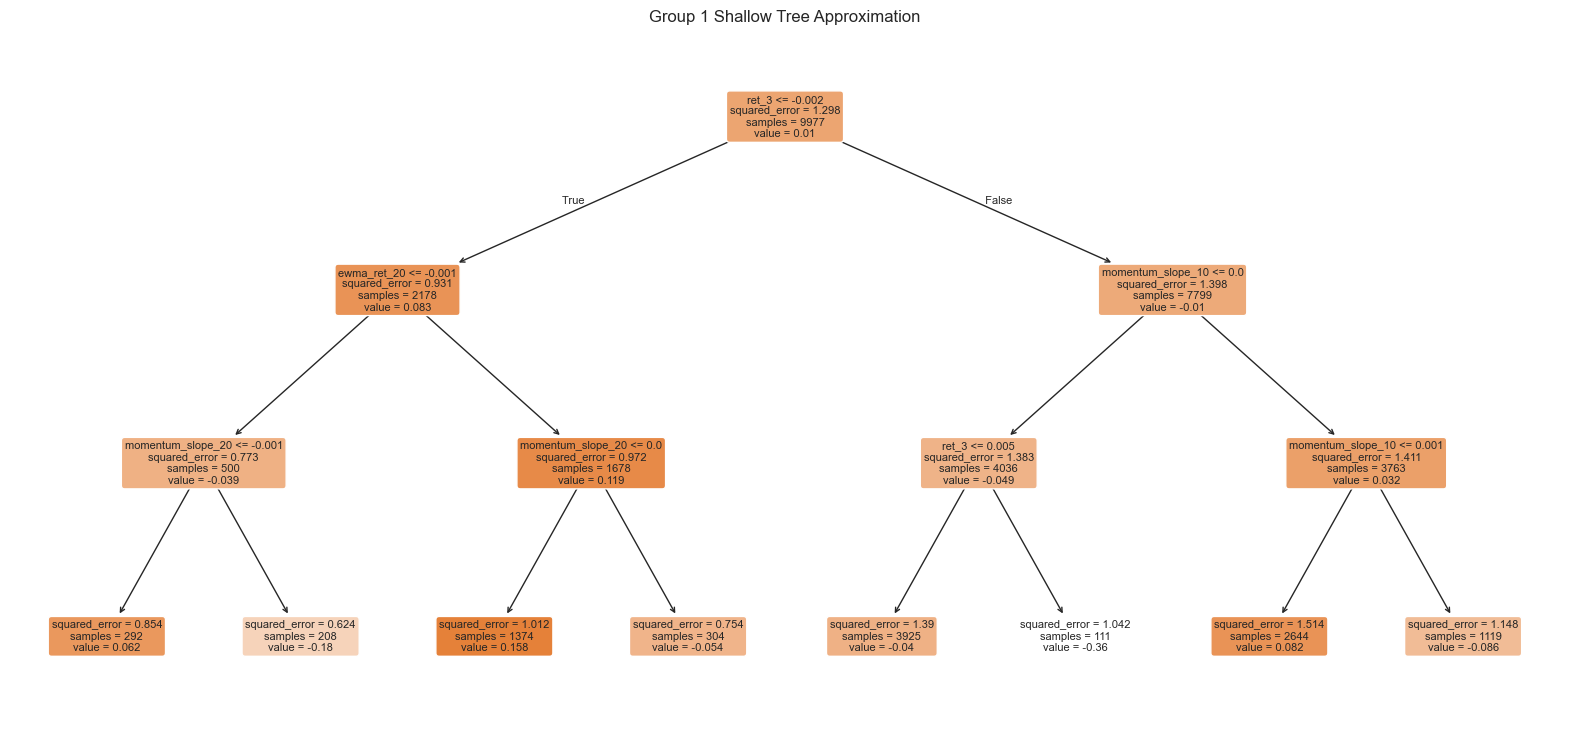

,importance
momentum_slope_10,0.238899
ewma_ret_20,0.149073
ret_3,0.125295
ret_10,0.100875
ret_5,0.093760
ewma_ret_5,0.081240
momentum_slope_20,0.069260
ewma_ret_10,0.050777
ret_1,0.045723
ret_2,0.045098


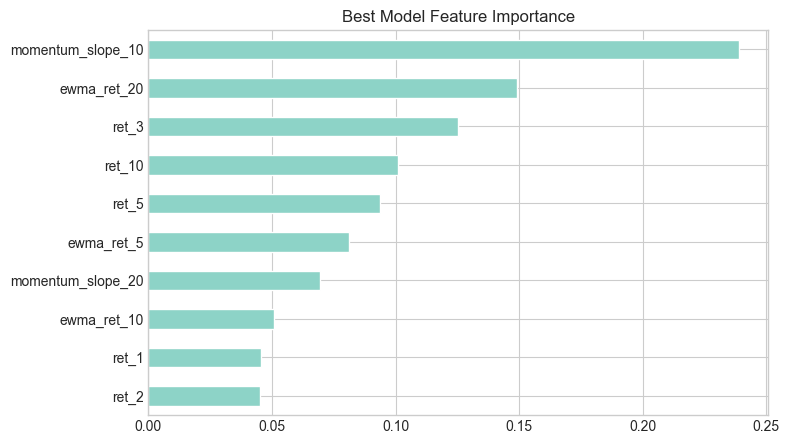

In [12]:
target_col = f"target_{BEST_HORIZON}"
train_frame = data[GROUP1_FEATURES + [target_col]].replace([np.inf, -np.inf], np.nan).dropna()

tree_probe = DecisionTreeRegressor(max_depth=MAX_TREE_DEPTH, min_samples_leaf=50, random_state=RANDOM_STATE)
tree_probe.fit(train_frame[GROUP1_FEATURES], train_frame[target_col])
print(export_text(tree_probe, feature_names=GROUP1_FEATURES, decimals=6))

plt.figure(figsize=(20, 9))
plot_tree(tree_probe, feature_names=GROUP1_FEATURES, filled=True, rounded=True, fontsize=8)
plt.title("Group 1 Shallow Tree Approximation")
plt.show()

final_model = clone(models[BEST_MODEL])
final_model.fit(train_frame[GROUP1_FEATURES], train_frame[target_col])
importance = pd.Series(final_model.feature_importances_, index=GROUP1_FEATURES).sort_values(ascending=False)
display(importance.to_frame("importance"))
importance.sort_values().plot(kind="barh", figsize=(8, 5), title="Best Model Feature Importance")
plt.show()

## 11. Next Robustness Checks

- Increase `FEE_RATE` and `SLIPPAGE` to conservative broker-realistic assumptions.
- Test `ENTRY_THRESHOLD` using train-only prediction quantiles rather than zero.
- Compare expanding training windows with rolling 3-year windows.
- Freeze the selected model and evaluate the latest year as a final holdout.
- Inspect losing years manually for range-bound behavior, trend reversals, and volatility regime shifts.